In [1]:
library(torch)
library(luz)
#library(lecospectR)

In [2]:
source("./Functions/lecospectR.R")

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: compiler

Loading required package: raster

Loading required package: sp


Attaching package: ‘raster’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: hsdar

Loading required package: rgdal

Please note that rgdal will be retired during October 2023,
plan transition to sf/stars/terra functions using GDAL and PROJ
at your earliest convenience.
See https://r-spatial

In [3]:
net <- nn_module(
    "jigsaw",
     initialize = function(num_components = NUM_VARS, num_levels = 8) {
      self$internal_dimension <- 256
      self$A <- nn_conv1d(
        in_channels = num_components, 
        out_channels = self$internal_dimension,
        kernel_size = 1, 
        padding = 1)

      # define the B block;
      self$B3 <- nn_sequential(
        nn_conv1d(self$internal_dimension,6,1, padding = 1), 
        nn_conv1d(6,9,3))
      self$B5 <- nn_sequential(
        nn_conv1d(self$internal_dimension,10,1, padding = 3), 
        nn_conv1d(10,9,5))
      self$B7 <- nn_sequential(
        nn_conv1d(self$internal_dimension,128,1, padding = 5), 
        nn_conv1d(128,9,7))
      self$B9 <- nn_sequential(
        nn_conv1d(self$internal_dimension,128,1, padding = 7), 
        nn_conv1d(128,9,9))

    self$B <- nn_sequential(
      nn_adaptive_avg_pool1d(
        self$internal_dimension
      ), 
      nn_flatten(), 
      nn_linear(
        in_features = 2304,# concatenated dimension
        out_features = self$internal_dimension
      ), 
      nn_dropout(p = 0.4)
      )



      #C block
      self$C <- nn_sequential(
        nn_flatten(start_dim = 2,end_dim = -1),
        nn_linear(
          in_features = 768, # A 
          out_features = 768
        ), 
        nn_relu(),
        nn_dropout(p = 0.4),
        nn_linear(
          in_features = 768, 
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.4),
        nn_relu()
      )

      self$D <- nn_sequential(
        nn_linear(
          in_features = 2 * self$internal_dimension,
          out_features = self$internal_dimension
        ),
        nn_dropout(p = 0.4),
        nn_relu(),
        nn_linear(
          in_features = self$internal_dimension,
          out_features = 8
        )
      )
    
  },

  forward = function(x) {
    x_A <- self$A(x)
    x_b3 <- self$B3(x_A)
    x_b5 <- self$B5(x_A)
    x_b7 <- self$B7(x_A)
    x_b9 <- self$B9(x_A)


    #print(paste0("A: ", dim(x_A)))
    #print(paste0("B3: ", dim(x_b3)))
    #print(paste0("B5: ", dim(x_b5)))
    #print(paste0("B7: ", dim(x_b7)))
    #print(paste0("B9: ", dim(x_b9)))

    x_B_concat <- torch_cat(tensors = list(
      x_b3, 
      x_b5, 
      x_b7, 
      x_b9
    ), dim = 3)

    x_B <- self$B(x_B_concat)
    #print(paste0("B: ", dim(x_B)))

    x_C <- self$C(x_A)
    #print(paste0("C: ", dim(x_C)))


    x_D <- self$D(
      torch_cat(
        tensors = list(
          x_B, 
          x_C
        ), dim = 2)
    )

    #class_label <- torch_argmax(x_D, dim = 2)
    #print(paste0("D: ", dim(x_D)))

    return(x_D)
  }

  
)

In [4]:
add_channel_dim <- function(img) {
   x <- img$unsqueeze(1)
   return(torch_transpose(x, 1,2))
}

In [5]:
create_variable_names <- function(start, stop){
    names <- c()
    for(i in start:stop){
        names <- append(
            names, 
            paste0("X", i))
    }

    return(names)
}

In [6]:
independent_variables <- create_variable_names(400L, 999L)

dependent_variable <- "FncGrp1" 
NUM_VARS <- length(independent_variables)
print(length(independent_variables))

[1] 600


In [7]:
# define the dataset
data_df <- read.csv(file = "Data/Ground_Validation/PFT_image_spectra/PFT_Image_SpectralLib_Clean.csv")


In [8]:

lecospec_dataset <- torch::dataset(
    name = "lecospec_image",
    initialize = function(df, transform = function(x){x}) {
        self$x <- as.matrix(df[, independent_variables])
        self$y <- torch_tensor(
            as.matrix(
                as.integer(
                    as.factor(
                        df[, dependent_variable]
                        )
                    )
                )
            )
        self$transform <- transform
    },

    .getitem = function(i) {
        list(
            x = self$transform(torch_flatten(self$x[i,])),
            y = torch_flatten(self$y[i])$squeeze()
        )
    },

    .length = function() {
        self$y$size()[[1]]
    }
)

In [9]:
head(data_df)

,X,UID,ScanNum,sample_name,PFT,FncGrp1,Site,X398,X399,X400,⋯,X990,X991,X992,X993,X994,X995,X996,X997,X998,X999
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,BisonGulchPFTsBetula1,1,spec_1,Betula,ShrubDecid,BisonGulch,0.05814769,0.05926529,0.06028869,⋯,0.6815182,0.6811660,0.6890470,0.7040298,0.7249807,0.7507566,0.7801884,0.8121027,0.8453261,0.8786852
2,2,BisonGulchPFTsBetula1,1,spec_2,Betula,ShrubDecid,BisonGulch,0.04456014,0.04778814,0.05079318,⋯,0.6706666,0.6683159,0.6786394,0.7000307,0.7308801,0.7695067,0.8140391,0.8625739,0.9132079,0.9640378
3,3,BisonGulchPFTsBetula1,1,spec_3,Betula,ShrubDecid,BisonGulch,0.03929324,0.04265593,0.04557066,⋯,0.5152525,0.5091915,0.5178217,0.5395294,0.5726982,0.6156166,0.6663192,0.7227978,0.7830447,0.8450520
4,4,BisonGulchPFTsBetula1,1,spec_4,Betula,ShrubDecid,BisonGulch,0.13230228,0.11122692,0.09129034,⋯,0.5120581,0.5113880,0.5348292,0.5745538,0.6227243,0.6723311,0.7185860,0.7570701,0.7833644,0.7930498
5,5,BisonGulchPFTsBetula1,1,spec_5,Betula,ShrubDecid,BisonGulch,0.05211388,0.05565497,0.05878525,⋯,0.6863419,0.6680365,0.6509006,0.6344450,0.6181806,0.6017555,0.5851848,0.5685449,0.5519121,0.5353626
6,6,BisonGulchPFTsBetula1,1,spec_6,Betula,ShrubDecid,BisonGulch,0.06955397,0.06788242,0.06631141,⋯,0.7354495,0.7371508,0.7445194,0.7567953,0.7732173,0.7930235,0.8154512,0.8397375,0.8651196,0.8908347


In [10]:
num_per_pft <- 300
train_test_data <- create_patch_balanced_sample(
    data_df,
    test_count = 20,
    train_count = NULL,
    verbose = FALSE
    )

split_2_train <- create_patch_balanced_sample(
    train_test_data$remainder,
    test_count = num_per_pft,
    train_count = 1000,
    verbose = FALSE
    )

In [11]:
print(names(split_2_train))

[1] "selection"         "remainder"         "samples_per_patch"
[4] "samples_per_class"


In [12]:
print(split_2_train$selection)

      X                   UID ScanNum sample_name    PFT        FncGrp1
21   21 BisonGulchPFTsBetula1       1     spec_21 Betula     ShrubDecid
12   12 BisonGulchPFTsBetula1       1     spec_12 Betula     ShrubDecid
18   18 BisonGulchPFTsBetula1       1     spec_18 Betula     ShrubDecid
6     6 BisonGulchPFTsBetula1       1      spec_6 Betula     ShrubDecid
1     1 BisonGulchPFTsBetula1       1      spec_1 Betula     ShrubDecid
11   11 BisonGulchPFTsBetula1       1     spec_11 Betula     ShrubDecid
9     9 BisonGulchPFTsBetula1       1      spec_9 Betula     ShrubDecid
5     5 BisonGulchPFTsBetula1       1      spec_5 Betula     ShrubDecid
23   23 BisonGulchPFTsBetula1       1     spec_23 Betula     ShrubDecid
10   10 BisonGulchPFTsBetula1       1     spec_10 Betula     ShrubDecid
15   15 BisonGulchPFTsBetula1       1     spec_15 Betula     ShrubDecid
22   22 BisonGulchPFTsBetula1       1     spec_22 Betula     ShrubDecid
62   62 BisonGulchPFTsBetula2       2     spec_37 Betula     Shr

In [13]:
train_indices <- sample(1:nrow(data_df), 250)
train_ds <- lecospec_dataset(
    split_2_train$selection,
    transform = add_channel_dim
    )
valid_ds <- lecospec_dataset(
    train_test_data$selection, 
    transform = add_channel_dim
    )

length(train_ds)
length(valid_ds)

[1] 2222

[1] 160

In [40]:
# create a dataloader
test_dl <- torch::dataloader(
    valid_ds,
    batch_size = 80,
    shuffle = FALSE
)

train_dl <- torch::dataloader(
    train_ds,
    batch_size = 240,
    shuffle = TRUE
)

In [33]:
batch <- dataloader_make_iter(train_dl) %>% dataloader_next()
print(dim(batch$x))
print(dim(batch$y))

[1] 240 600   1
[1] 240


In [16]:
print(batch$x$shape)

[1] 240 600   1


In [17]:
print(batch$y$shape)

[1] 240


In [18]:
model <- net()
model(batch$x)


torch_tensor
0.01 *
 1.3175  0.5157  2.6235 -4.3280  5.0977  4.0270 -0.8134 -6.6622
  3.8329 -0.1831 -1.9129 -4.6748  6.1612  2.9268 -2.8012 -4.6699
  4.6111 -0.4801  2.8562 -6.9241  5.4490  1.5109 -1.0764 -5.6358
  2.4452  0.5425  2.0294 -5.8121  2.6748  2.7414 -1.7998 -4.9999
  1.5149  0.7111  1.1697 -4.7993  3.7658  3.7908 -2.2106 -0.9028
  1.4457 -1.9015  0.6193 -6.1748  4.5242  1.0863 -2.7304 -5.5571
  2.2212  1.0677  1.8596 -3.9480  5.6375  1.9375 -0.2320 -4.0065
  4.3422  0.7639  2.3951 -5.5889  3.8386  5.3156 -0.2466 -4.1817
  2.5321 -2.9995  0.5751 -6.5213  5.5100  3.4082 -1.7211 -3.4763
  2.8750 -0.4398 -1.1865 -4.4616  6.5901  2.6819 -1.8038 -1.7535
  3.3759  0.5776  3.0143 -5.1518  3.4243  3.6977  1.1188 -3.7881
  4.1109  1.0995 -0.1911 -5.0799  4.2434  3.9412  0.6442 -6.3811
  3.2937 -0.4799 -2.1886 -3.6366  3.3034  4.5194 -2.6710 -5.4388
  3.2493 -0.8516 -1.3475 -5.8044  3.0230  3.8706 -1.3749 -3.4655
  1.5149 -0.9543  0.5659 -5.7013  5.3359  4.2854 -2.4630 -3.9586
  5.23

In [19]:
batch$y

torch_tensor
 4
 4
 8
 4
 1
 8
 3
 3
 2
 7
 8
 3
 5
 5
 3
 4
 4
 7
 6
 3
 5
 5
 6
 2
 2
 4
 4
 4
 4
 6
... [the output was truncated (use n=-1 to disable)]
[ CPULongType{240} ]

In [20]:
net_fitted <- net %>%
  setup(
    loss = nn_cross_entropy_loss(),
    optimizer = optim_adam
  ) %>%
  set_opt_hparams(lr = 0.001) %>% 
  fit(
    train_dl, 
    epochs = 500, 
    valid_data = test_dl
    )

In [21]:
net_fitted

A `luz_module_fitted`
── Time ────────────────────────────────────────────────────────────────────────
• Total time: 38m 25.8s
• Avg time per training epoch: 4.5s

── Results ─────────────────────────────────────────────────────────────────────
Metrics observed in the last epoch.

ℹ Training:
loss: 0.1788

── Model ───────────────────────────────────────────────────────────────────────
An `nn_module` containing 1,753,760 parameters.

── Modules ─────────────────────────────────────────────────────────────────────
• A: <nn_conv1d> #153,856 parameters
• B3: <nn_sequential> #1,713 parameters
• B5: <nn_sequential> #3,029 parameters
• B7: <nn_sequential> #40,969 parameters
• B9: <nn_sequential> #43,273 parameters
• B: <nn_sequential> #590,080 parameters
• C: <nn_sequential> #787,456 parameters
• D: <nn_sequential> #133,384 parameters

In [41]:
predict(net_fitted,newdata = batch$x)

torch_tensor
-54.0467 -46.0430 -15.2485 -27.9778  16.6768 -67.3778  -5.5720 -20.0859
-69.9350 -75.1125 -24.1891 -34.9016  23.0295 -73.7637  -1.1217 -31.5514
-66.4226 -65.6874 -13.7598 -37.6567  17.4888 -97.9488  -6.6307 -26.7813
-60.1399 -65.2948 -21.5869 -26.6787  19.2729 -70.4499  -5.0059 -34.1492
-57.3713 -66.6591 -19.8213 -23.9960  18.4119 -71.7091  -8.3586 -33.4497
-60.1941 -61.6523 -22.7035 -24.4395  20.2755 -70.8021  -9.5995 -38.6478
-66.8120 -71.4566 -16.8087 -32.4472  19.9449 -90.5310 -10.1546 -32.8273
-76.0731 -74.5452 -30.4827 -37.1025  24.9586 -70.2249   0.5449 -38.0496
-51.5351 -63.1642 -16.7249 -21.1972  16.6927 -68.7100 -12.0604 -31.4095
-63.4024 -60.7091 -26.4424 -31.6042  19.1766 -61.6493   2.6682 -31.5700
-67.5836 -61.6938 -24.5378 -26.0677  24.0192 -79.7600 -16.9530 -44.6704
-60.3884 -55.7906 -18.0058 -26.6256  18.7323 -79.6470 -14.4820 -32.1394
-49.1387  -9.6467 -33.6226 -32.6968  10.6218 -18.4202   8.5184  -8.9245
-45.3327 -10.3001 -36.1871 -28.4700   9.7828 -16.43

## Next

Need to define the correct nueral net architecture, and then the training loop should work as intended.  This is likely some kind of U-Net from a paper.  

Just a matter of finding the correct one and plugging the layers into the model above.  

Hopefully that works directly

In [42]:
preds <- predict(net_fitted, test_dl)

torch_tensor
Columns 1 to 6-7.3963e+01 -7.6167e+01 -1.5933e+01 -3.8405e+01  2.3370e+01 -1.0053e+02
-5.1098e+01 -9.3557e+00 -4.1296e+01 -3.5347e+01  1.0846e+01 -1.4939e+01
-1.6200e-01 -2.4019e+01 -1.2101e+00 -5.4501e+00  4.2685e+00  6.3043e+00
 2.0243e-01 -2.0265e+01 -3.3491e+00 -1.1194e+01  3.0194e+00  7.4501e+00
 2.1818e+00 -1.5714e+01 -6.0381e+00 -7.1241e+00  2.0102e+00  7.3687e+00
-1.5244e-01 -2.9372e+01 -4.6404e+00 -1.3799e+01  5.5811e+00  1.0942e+01
-1.9850e+00 -2.4173e+01 -1.5355e+00 -1.0949e+01  6.6389e+00  7.7546e+00
-6.2312e+00 -5.9511e+00 -5.3434e-01 -1.2338e+01  2.1833e+00 -2.9772e+00
 1.6198e+00 -2.3609e+01  1.0957e+00 -2.6382e+00  1.8267e+00  7.6686e+00
 1.2100e+00 -3.2074e+01 -2.4421e-01 -8.4893e+00  4.6672e+00  1.1346e+01
 4.2038e+00 -1.7400e+01 -2.7235e+00  1.7938e+00 -3.7688e+00  2.9197e+00
 2.6307e+00 -1.5313e+01 -2.3229e+00 -1.7450e+00 -9.6564e-01  5.2521e+00
 3.9067e+00 -2.3743e+01  6.0448e+00 -1.8171e+01  9.0167e-01  3.1842e+00
 2.3041e+00 -1.3001e+01  1.8379e-01 -

List of 138
 $ line                            :List of 6
  ..$ colour       : chr "black"
  ..$ linewidth    : num 0.5
  ..$ linetype     : num 1
  ..$ lineend      : chr "butt"
  ..$ arrow        : logi FALSE
  ..$ inherit.blank: logi TRUE
  ..- attr(*, "class")= chr [1:2] "element_line" "element"
 $ rect                            :List of 5
  ..$ fill         : chr "white"
  ..$ colour       : chr "black"
  ..$ linewidth    : num 0.5
  ..$ linetype     : num 1
  ..$ inherit.blank: logi TRUE
  ..- attr(*, "class")= chr [1:2] "element_rect" "element"
 $ text                            :List of 11
  ..$ family       : chr ""
  ..$ face         : chr "plain"
  ..$ colour       : chr "black"
  ..$ size         : num 11
  ..$ hjust        : num 0.5
  ..$ vjust        : num 0.5
  ..$ angle        : num 0
  ..$ lineheight   : num 0.9
  ..$ margin       : 'margin' num [1:4] 0points 0points 0points 0points
  .. ..- attr(*, "unit")= int 8
  ..$ debug        : logi FALSE
  ..$ inherit.blank: l

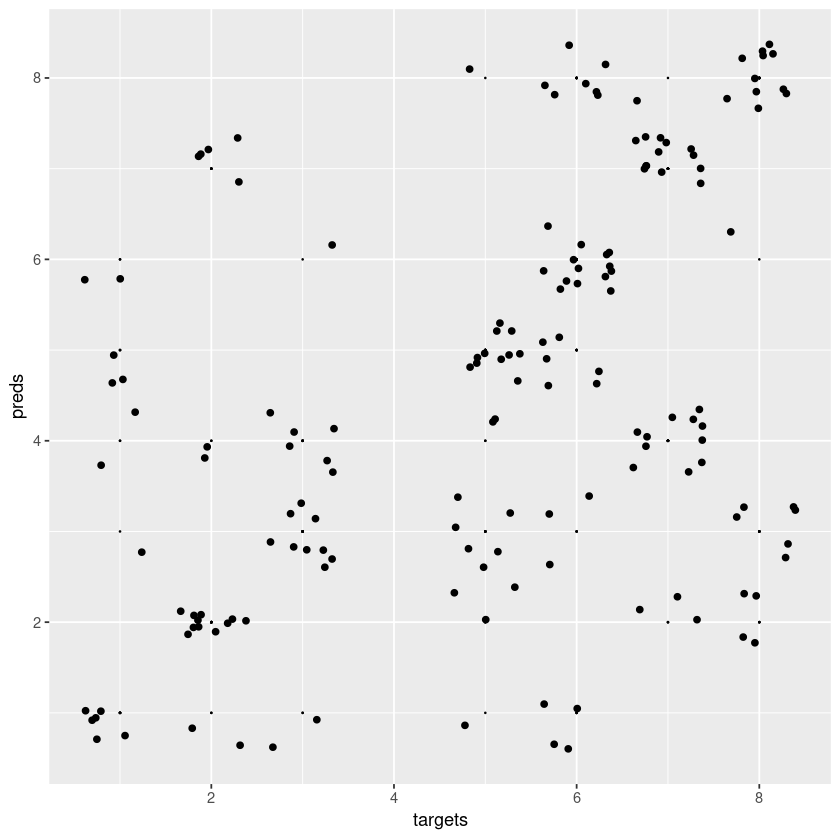

In [43]:
#test_dl <- dataloader(valid_ds, batch_size = 5000)
targets <- (test_dl %>% dataloader_make_iter() %>% dataloader_next())$y %>% as.numeric()

y_pred <- torch_argmax(preds, dim = 2) %>% as.numeric()
df <- data.frame(preds = y_pred, targets = targets)
#library(ggplot2)

print(preds)


ggplot(df, aes(x = targets, y = preds)) +
  geom_point(size = 0.1) +
  geom_jitter()
  theme_classic() +
  xlab("true correlations") +
  ylab("model predictions")

#plot(y_pred, targets)


In [54]:
df$preds %>% as.factor() %>% levels()

[1] "1" "2" "3" "4" "5" "6" "7" "8"

In [57]:
df$targets %>% as.factor() %>% levels()

[1] "1" "2" "3" "5" "6" "7" "8"

In [58]:
target_f <- df$targets %>% as.factor()
levels(target_f) <- c(levels(target_f), '4')

In [60]:
caret::confusionMatrix(
    df$preds %>% as.factor(),
    target_f
)

Warning message in confusionMatrix.default(df$preds %>% as.factor(), target_f):
“Levels are not in the same order for reference and data. Refactoring data to match.”


Confusion Matrix and Statistics

          Reference
Prediction  1  2  3  5  6  7  8  4
         1  6  2  2  1  4  0  0  0
         2  0 11  0  3  0  3  4  0
         3  1  0  9  6  3  0  6  0
         5  3  0  0 11  6  0  0  0
         6  2  0  1  0 14  0  1  0
         7  0  5  0  0  0 13  0  0
         8  0  0  0  1  7  1 11  0
         4  2  2  6  2  0 11  0  0

Overall Statistics
                                          
               Accuracy : 0.4688          
                 95% CI : (0.3895, 0.5492)
    No Information Rate : 0.2125          
    P-Value [Acc > NIR] : 5.204e-13       
                                          
                  Kappa : 0.3951          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: 1 Class: 2 Class: 3 Class: 5 Class: 6 Class: 7
Sensitivity           0.42857  0.55000  0.50000  0.45833   0.4118  0.46429
Specificity           0.93836  0.92857  0.88732  0.9

In [25]:
luz_save(obj = net_fitted,path = "./dl_linear_v0.dat")